# Phase 5 — Municipal Typology, Vulnerability Scoring & Net Migration Modeling

This notebook implements the remaining strategy-page elements:

- **0–1 vulnerability scoring**
- **K-means clustering**
- **hierarchical clustering**
- **municipal typology profiling**
- **explicit net migration modeling** (when birth/death columns are available)

It is designed to run from the `analysis/` folder and reuse:
- `../data/processed_puerto_rico_data.csv`

## Objectives

This phase helps align the implementation with the strategy section of the project website by adding:
- a planner-facing vulnerability score
- municipal typologies based on clustering
- hierarchical structure across municipalities
- a net migration modeling component when supporting demographic columns are present

## 1. Load libraries and processed data

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

analysis_dir = Path(".")
data_path = Path("../data/processed_puerto_rico_data.csv")

if not data_path.exists():
    raise FileNotFoundError(f"Could not find processed dataset at: {data_path}")

df = pd.read_csv(data_path)
print("Processed data shape:", df.shape)
df.head()

Processed data shape: (936, 65)


,year,municipio,geoid,total_population,total_population_moe,total_population_16plus,total_population_16plus_moe,total_housing_units,total_housing_units_moe,unemployment_rate_pct,...,burglary_rate,target_pop_change,lag_violent_crime_rate,lag_property_crime_rate,lag_pop_change_1,lag_pop_change_2,income_growth,per_capita_income_inv,split,vulnerability_index
0,2013,Adjuntas,72001,19334,0,15087,79,7298,140,27.2,...,3.206786,-0.637270,0.411142,5.550416,-0.286973,-0.138171,-13.238321,-7235,train,3.251755
1,2014,Adjuntas,72001,19188,0,15080,88,7514,136,34.0,...,1.667709,-0.755146,0.465501,3.206786,-0.637270,-0.286973,-9.938596,-7042,train,3.443797
2,2015,Adjuntas,72001,18962,0,15022,85,7694,126,36.5,...,1.898534,-1.177819,0.312695,1.667709,-0.755146,-0.637270,-0.603827,-7270,train,3.105204
3,2016,Adjuntas,72001,18760,0,14963,78,7673,143,35.6,...,1.599147,-1.065288,0.158211,1.898534,-1.177819,-0.755146,6.244712,-7124,train,2.806677
4,2017,Adjuntas,72001,18525,0,14895,100,7705,150,40.9,...,1.457490,-1.252665,1.066098,1.599147,-1.065288,-1.177819,1.241554,-7117,train,2.701164


## 2. Build the latest-year municipal snapshot

Typology analysis is more interpretable when constructed from a single municipal cross-section.
This notebook uses the latest available year in the processed dataset.

In [2]:
if "year" not in df.columns or "municipio" not in df.columns:
    raise ValueError("Dataset must include 'year' and 'municipio' columns.")

latest_year = int(df["year"].max())
latest_df = df[df["year"] == latest_year].copy().reset_index(drop=True)

print("Latest year:", latest_year)
print("Municipal rows in latest snapshot:", latest_df.shape[0])

latest_df[["municipio", "year"]].head()

Latest year: 2024
Municipal rows in latest snapshot: 78


,municipio,year
0,Adjuntas,2024
1,Aguada,2024
2,Aguadilla,2024
3,Aguas Buenas,2024
4,Aibonito,2024


## 3. Create the final 0–1 vulnerability score

The earlier phases already generated a PCA-based `vulnerability_index`.
This section rescales that index to a 0–1 range so it can be used as a simpler planner-facing metric.

In [3]:
if "vulnerability_index" not in latest_df.columns:
    raise ValueError("Expected 'vulnerability_index' column in processed dataset.")

scaler = MinMaxScaler()
latest_df["vulnerability_score_0_1"] = scaler.fit_transform(
    latest_df[["vulnerability_index"]]
)

latest_df[["municipio", "vulnerability_index", "vulnerability_score_0_1"]].head()

,municipio,vulnerability_index,vulnerability_score_0_1
0,Adjuntas,-0.662450,1.000000
1,Aguada,-2.571220,0.780144
2,Aguadilla,-3.391187,0.685698
3,Aguas Buenas,-3.030436,0.727250
4,Aibonito,-2.818050,0.751713


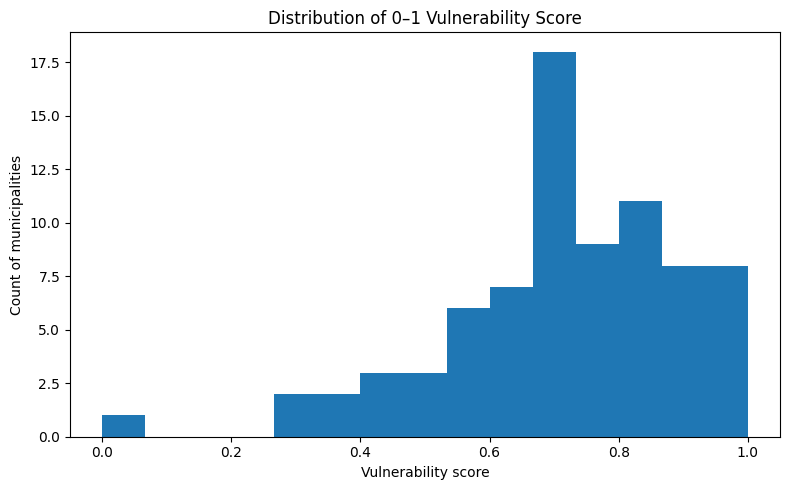

In [4]:
plt.figure(figsize=(8, 5))
plt.hist(latest_df["vulnerability_score_0_1"], bins=15)
plt.title("Distribution of 0–1 Vulnerability Score")
plt.xlabel("Vulnerability score")
plt.ylabel("Count of municipalities")
plt.tight_layout()
plt.show()

## 4. Select clustering variables

This section builds a municipal feature set for typology analysis.
It prioritizes interpretable variables already present in the processed dataset.

In [5]:
preferred_cluster_cols = [
    "vulnerability_score_0_1",
    "median_income_real",
    "income_growth",
    "max_wind_knots",
    "max_seismic_mag",
    "lag_violent_crime_rate",
    "lag_property_crime_rate",
    "lag_pop_change_1",
    "lag_pop_change_2",
]

cluster_cols = [c for c in preferred_cluster_cols if c in latest_df.columns]

if len(cluster_cols) < 3:
    raise ValueError(
        f"Not enough clustering columns found. Available matches: {cluster_cols}"
    )

cluster_df = latest_df[cluster_cols].copy()
cluster_df = cluster_df.replace([np.inf, -np.inf], np.nan)
cluster_df = cluster_df.fillna(cluster_df.median(numeric_only=True))

scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(cluster_df)

cluster_cols

['vulnerability_score_0_1',
 'median_income_real',
 'income_growth',
 'max_wind_knots',
 'max_seismic_mag',
 'lag_violent_crime_rate',
 'lag_property_crime_rate',
 'lag_pop_change_1',
 'lag_pop_change_2']

## 5. K-means clustering

We first examine an elbow plot to inspect how inertia changes across different numbers of clusters.
Then we fit a 4-cluster solution for municipal typology analysis.

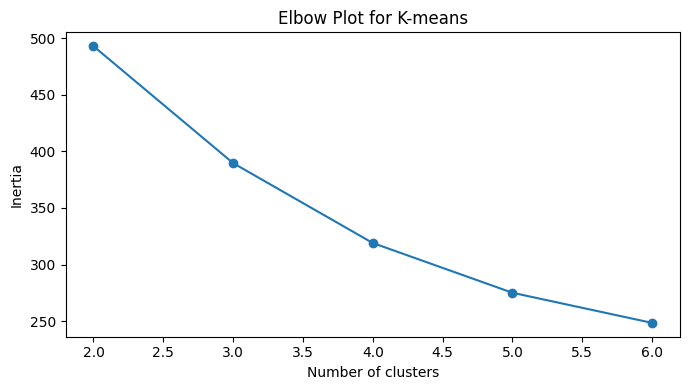

In [6]:
inertias = []
k_values = range(2, 7)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(k_values), inertias, marker="o")
plt.title("Elbow Plot for K-means")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

In [7]:
# Compare 4-cluster and 3-cluster K-means solutions
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=20)
latest_df["kmeans_cluster_4"] = kmeans_4.fit_predict(X_cluster)

kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=20)
latest_df["kmeans_cluster_3"] = kmeans_3.fit_predict(X_cluster)

print("K-means cluster counts (4 clusters):")
print(latest_df["kmeans_cluster_4"].value_counts().sort_index())

print("\nK-means cluster counts (3 clusters):")
print(latest_df["kmeans_cluster_3"].value_counts().sort_index())

latest_df[["municipio", "kmeans_cluster_4", "kmeans_cluster_3"]].head()

K-means cluster counts (4 clusters):
kmeans_cluster_4
0    19
1    14
2    44
3     1
Name: count, dtype: int64

K-means cluster counts (3 clusters):
kmeans_cluster_3
0    32
1    45
2     1
Name: count, dtype: int64


,municipio,kmeans_cluster_4,kmeans_cluster_3
0,Adjuntas,0,1
1,Aguada,2,1
2,Aguadilla,0,1
3,Aguas Buenas,2,1
4,Aibonito,2,1


## 6. Hierarchical clustering

Hierarchical clustering provides a second clustering perspective and helps visualize nested municipal similarity.

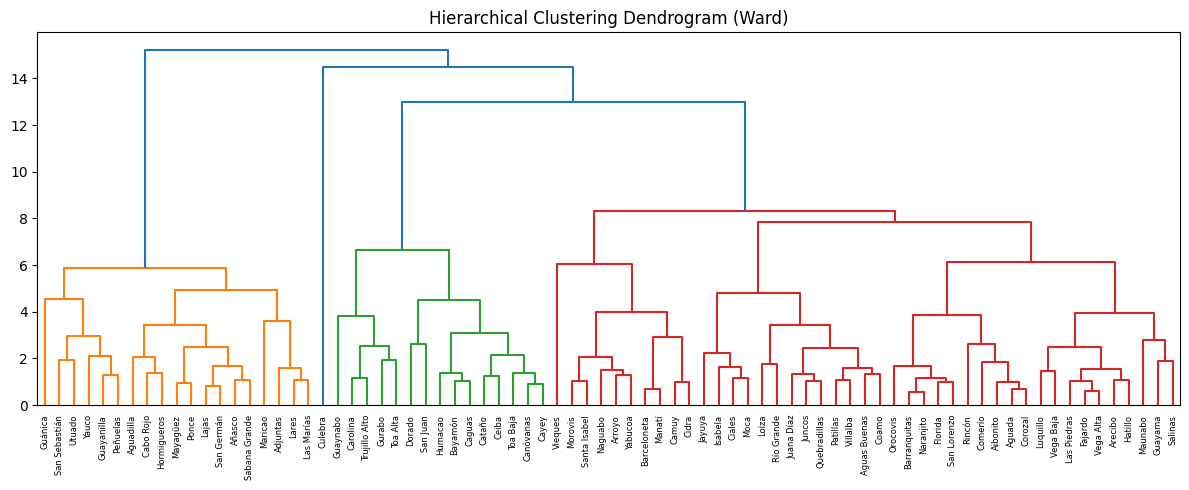

In [8]:
Z = linkage(X_cluster, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, labels=latest_df["municipio"].tolist(), leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram (Ward)")
plt.tight_layout()
plt.show()

In [9]:
# Compare 4-cluster and 3-cluster hierarchical solutions
latest_df["hier_cluster_4"] = fcluster(Z, t=4, criterion="maxclust")
latest_df["hier_cluster_3"] = fcluster(Z, t=3, criterion="maxclust")

print("Hierarchical cluster counts (4 clusters):")
print(latest_df["hier_cluster_4"].value_counts().sort_index())

print("\nHierarchical cluster counts (3 clusters):")
print(latest_df["hier_cluster_3"].value_counts().sort_index())

latest_df[["municipio", "hier_cluster_4", "hier_cluster_3"]].head()

Hierarchical cluster counts (4 clusters):
hier_cluster_4
1    19
2    15
3    43
4     1
Name: count, dtype: int64

Hierarchical cluster counts (3 clusters):
hier_cluster_3
1    19
2    58
3     1
Name: count, dtype: int64


,municipio,hier_cluster_4,hier_cluster_3
0,Adjuntas,1,1
1,Aguada,3,2
2,Aguadilla,1,1
3,Aguas Buenas,3,2
4,Aibonito,3,2


In [10]:
comparison_df = latest_df[
    [
        "municipio",
        "kmeans_cluster_4",
        "kmeans_cluster_3",
        "hier_cluster_4",
        "hier_cluster_3",
        "vulnerability_score_0_1",
        "lag_pop_change_1",
        "median_income_real"
    ]
].copy()

comparison_df.head(20)

,municipio,kmeans_cluster_4,kmeans_cluster_3,hier_cluster_4,hier_cluster_3,vulnerability_score_0_1,lag_pop_change_1,median_income_real
0,Adjuntas,0,1,1,1,1.000000,0.016693,20352.27
1,Aguada,2,1,3,2,0.780144,-0.247381,22384.47
2,Aguadilla,0,1,1,1,0.685698,-0.485827,22425.08
3,Aguas Buenas,2,1,3,2,0.727250,-1.027511,24020.03
4,Aibonito,2,1,3,2,0.751713,0.223987,22637.46
5,Arecibo,2,0,3,2,0.658795,-0.392125,24606.16
6,Arroyo,2,0,3,2,0.855030,-1.417991,22056.53
7,Añasco,0,1,1,1,0.689506,-0.709887,25440.07
8,Barceloneta,2,0,3,2,0.708932,-0.172536,25515.03
9,Barranquitas,2,1,3,2,0.878917,0.294128,24368.79


## 7. Municipal typology profiling

This section summarizes each K-means group using the mean values of the cluster variables.
It also assigns a simple rule-based typology label for interpretation.

In [11]:
typology_profile = latest_df.groupby("kmeans_cluster_3")[cluster_cols].mean().round(3)
typology_profile

,vulnerability_score_0_1,median_income_real,income_growth,max_wind_knots,max_seismic_mag,lag_violent_crime_rate,lag_property_crime_rate,lag_pop_change_1,lag_pop_change_2
kmeans_cluster_3,,,,,,,,,
0,0.599,29946.918,2.555,0.0,0.000,0.628,0.879,-0.501,-1.231
1,0.804,23102.110,2.513,0.0,1.849,0.229,0.524,-0.616,-1.180
2,0.525,30847.490,4.224,0.0,0.000,0.000,1.561,8.010,-8.275


In [12]:
def assign_typology_label(row):
    if (
        row["vulnerability_score_0_1"] >= latest_df["vulnerability_score_0_1"].quantile(0.75)
        and row.get("lag_pop_change_1", 0) < 0
    ):
        return "High vulnerability decline"

    if (
        row.get("lag_pop_change_1", 0) >= 0
        and row.get("median_income_real", 0) >= latest_df["median_income_real"].median()
    ):
        return "Relative resilience / stabilization"

    if row.get("max_wind_knots", 0) >= latest_df["max_wind_knots"].quantile(0.75):
        return "Disaster-exposed"

    return "Mixed transition"

latest_df["typology_label"] = latest_df.apply(assign_typology_label, axis=1)

latest_df[
    [
        "municipio",
        "kmeans_cluster_3",
        "hier_cluster_3",
        "typology_label",
        "vulnerability_score_0_1"
    ]
].head(15)

,municipio,kmeans_cluster_3,hier_cluster_3,typology_label,vulnerability_score_0_1
0,Adjuntas,1,1,Disaster-exposed,1.000000
1,Aguada,1,2,Disaster-exposed,0.780144
2,Aguadilla,1,1,Disaster-exposed,0.685698
3,Aguas Buenas,1,2,Disaster-exposed,0.727250
4,Aibonito,1,2,Disaster-exposed,0.751713
5,Arecibo,0,2,Disaster-exposed,0.658795
6,Arroyo,0,2,High vulnerability decline,0.855030
7,Añasco,1,1,Disaster-exposed,0.689506
8,Barceloneta,0,2,Disaster-exposed,0.708932
9,Barranquitas,1,2,Disaster-exposed,0.878917


## 8. Explicit net migration modeling

If birth and death fields are available, this section estimates a net migration proxy:

`net migration ≈ population change − natural change`

If those fields are not available in the processed dataset, the notebook records that status and continues.

In [13]:
birth_candidates = [c for c in latest_df.columns if "birth" in c.lower()]
death_candidates = [c for c in latest_df.columns if "death" in c.lower()]

net_migration_status = "not_available"

if birth_candidates and death_candidates:
    birth_col = birth_candidates[0]
    death_col = death_candidates[0]

    latest_df["net_migration_proxy"] = (
        latest_df["target_pop_change"] - (latest_df[birth_col] - latest_df[death_col])
    )

    net_migration_status = f"computed using {birth_col} and {death_col}"

    latest_df[
        ["municipio", birth_col, death_col, "net_migration_proxy"]
    ].head()

else:
    print("Birth/death columns not detected in processed dataset.")
    print("Birth candidates:", birth_candidates)
    print("Death candidates:", death_candidates)

    latest_df["net_migration_proxy"] = np.nan

net_migration_status

Birth/death columns not detected in processed dataset.
Birth candidates: []
Death candidates: []


'not_available'

## 9. Export typology outputs

In [14]:
typology_out = analysis_dir / "municipal_typologies_latest_year.csv"
profile_out = analysis_dir / "municipal_typology_profiles.csv"
summary_out = analysis_dir / "phase5_typology_summary.json"

latest_df.to_csv(typology_out, index=False)
typology_profile.to_csv(profile_out)

phase5_summary = {
    "latest_year": latest_year,
    "cluster_columns": cluster_cols,
    "net_migration_status": net_migration_status,
    "kmeans_cluster_counts": latest_df["kmeans_cluster_3"].value_counts().sort_index().to_dict(),
    "hier_cluster_counts": latest_df["hier_cluster_3"].value_counts().sort_index().to_dict()
}

with open(summary_out, "w") as f:
    json.dump(phase5_summary, f, indent=4)

print(f"Saved municipal typologies to: {typology_out}")
print(f"Saved typology profiles to: {profile_out}")
print(f"Saved Phase 5 summary to: {summary_out}")

Saved municipal typologies to: municipal_typologies_latest_year.csv
Saved typology profiles to: municipal_typology_profiles.csv
Saved Phase 5 summary to: phase5_typology_summary.json


## 10. Interpretation

This notebook completes the strategy-page elements related to:
- **municipal typology profiling**
- **0–1 vulnerability scoring**
- **clustering**
- **explicit migration modeling logic**

In your write-up, describe these outputs as:
- a planner-facing municipal typology layer
- a normalized vulnerability score for easier comparison
- a cross-sectional classification of late-period municipal conditions